# CNN

In [1]:
import torch
from torch import nn
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision
import torchvision.models #pretrained models
import torchvision.datasets # some datasets
import torchvision.transforms #manipulate our data
import torchmetrics

from torch.utils.data import DataLoader


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device
!nvidia-smi

Sun May 24 19:44:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.04              Driver Version: 596.21         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:F3:00.0 Off |                  N/A |
| N/A   41C    P8              6W /   33W |    2122MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
train_data = torchvision.datasets.FashionMNIST(
    root = "data", #where to dowwnload data
    train = True, #training dataset or test
    download=True, #download data
    transform = torchvision.transforms.ToTensor(), #transformation type
    target_transform=None #transforming labels
)
test_data = torchvision.datasets.FashionMNIST(
    root = "data", #where to dowwnload data
    train = False,
    download=True,
    transform = torchvision.transforms.ToTensor(),
    target_transform=None
)

In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

Text(0.5, 1.0, 'tensor(3)')

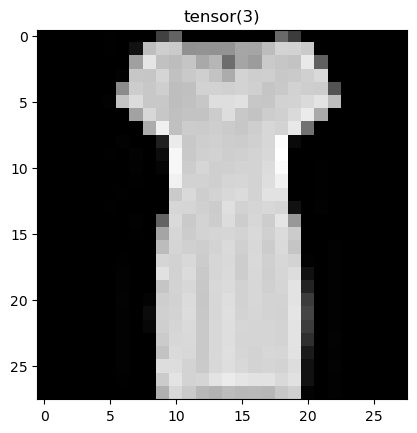

In [6]:
plt.imshow(train_data.data[20,:,:], cmap="gray")
plt.title(train_data.targets[20])

### We use mini-batches because they make training faster and more memory-efficient than full-batch training while giving more stable gradient updates than using one example at a time.

### DataLoader turns data into iterables (batches)

In [7]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False) #it is better not to shuffle test data
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x79a80adde650>,
 <torch.utils.data.dataloader.DataLoader at 0x79a80addc090>)

In [8]:
train_features, train_labels = next(iter(train_dataloader))
train_features.shape, train_labels.shape
# this is iterator and cannot use indexing: [0]
# for training we use this:
# for epoch in ranges(epochs):
#     for images,labels in train_dataloader:
#         train

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

# CNN Model
kernel -> like(3,3) ->if kernel=i -> size on each direction will decrease by i-1!

padding = 1 -> border -> size+2 in each direction ->preserves size and helps not loosing border information

stride -> jump of kernel on the input ->default = 1 

Output = floor((Input - Kernel + 2 × Padding) / Stride) + 1

pooling (max or average) -> reduces the size of input, for example, max pooling with a 2 kernel size just saves the maximum in every 2*2

``` 
nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
nn.MaxPool2d(kernel_size)
```

In [13]:
class FashinMNISTModel(nn.Module):
    def __init__(self, in_channels, hidden_units, out_features):
        super().__init__()
        self.in_channels = in_channels
        self.hidden_units = hidden_units
        self.out_features = out_features
        self.seq1 = nn.Sequential(nn.Conv2d(in_channels=in_channels,
                                            out_channels=hidden_units,
                                            kernel_size=3,
                                            stride=1,
                                            padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=hidden_units,
                                            out_channels=hidden_units,
                                            kernel_size=3,
                                            stride=1,
                                            padding=1),
                                  nn.ReLU(),
                                  nn.MaxPool2d(kernel_size=2))
        self.seq2 = nn.Sequential(nn.Conv2d(in_channels=hidden_units,
                                            out_channels=hidden_units,
                                            kernel_size=3,
                                            stride=1,
                                            padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels=hidden_units,
                                            out_channels=hidden_units,
                                            kernel_size=3,
                                            stride=1,
                                            padding=1),
                                  nn.ReLU(),
                                  nn.MaxPool2d(kernel_size=2))
        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(hidden_units*7*7,128),
                                        nn.ReLU(),
                                        nn.Linear(128,out_features))
        
        
    def forward(self,x):
        x = self.seq1(x)
        x = self.seq2(x)
        x = self.classifier(x)
        return x
        


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(43)
torch.cuda.manual_seed(42)
MyModel = FashinMNISTModel(1,10, 10).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= MyModel.parameters(), lr=0.01)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# timeit.default_timer

In [11]:
from timeit import default_timer as timer
start = timer()
summation=0
for i in range (1000000):
    summation +=i
end = timer()
print(end - start)

0.1583776739971654


In [12]:
EPOCHS = 4

torch.manual_seed(42)
torch.cuda.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

for epoch in tqdm(range(EPOCHS)):
    test_loss = 0
    train_loss = 0
    MyModel.train()
    for batch,(X,y) in enumerate(train_dataloader):
        X,y = X.to(device), y.to(device)
        y_pred = MyModel(X)
        loss = loss_function(y_pred, y)
        train_loss+=loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        
    MyModel.eval()
    with torch.inference_mode():
        for batch,(X_test,y_test) in enumerate(test_dataloader):
            X_test,y_test = X_test.to(device), y_test.to(device)
            y_test_pred = MyModel(X_test)
            loss = loss_function(y_test_pred,y_test)
            test_loss+=loss.item()
            
            
    print(f"epoch={epoch} , average_train_loss = {train_loss/len(train_dataloader)}, average_test_loss = {test_loss/len(test_dataloader)}")
    
    

  0%|          | 0/4 [00:00<?, ?it/s]

/pytorch/aten/src/ATen/native/cuda/Loss.cu:245: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [0,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:245: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [1,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:245: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [2,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:245: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [3,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:245: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [4,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:245: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [5,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/sr

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
